# Monomer Case II: QME

We solve the master equation {eq}`eq:qme-monomer-QD` numerically using the brute force method.  Since the equation is stiff, we need to use a fine time step. By default `mesolve` in QuTiP uses he stiff Adams/BDF algorithm which chooses an appropriate time step automatically. 

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

#--- Hamiltonian
H0 = 0*sigmaz()

gamma0 = 1.0
gamma_phi = 1e3
gamma_P = 10.0

c_ops = []
#--- pumping
c_ops.append(np.sqrt(gamma_P)*sigmap())
#--- dephsing
c_ops.append(np.sqrt(0.5*gamma_phi)*sigmaz())
#--- emission
c_ops.append(np.sqrt(gamma0)*sigmam())

rho_ss = steadystate(H0,c_ops)

In [32]:
#--- Detextion operator
D = sigmam()
#--- Intensity
I = expect(D.dag()*D,rho_ss)

## First-order coherence function

he first-order coherence function is expected to decay very quickly with the dephasing rate $\gamma_{\phi}$.  SInce we need to compute the evolution only for brief period, $\tau\gamma_{\phi} < 4$, numerical integration can be done easily.  The result agrees with theory perfectly.

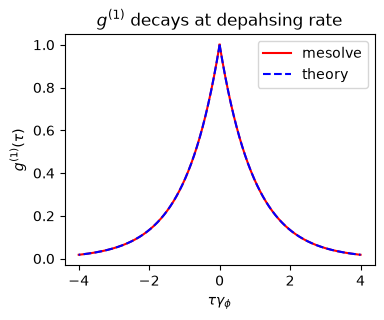

In [40]:
times = np.linspace(0,.004,1000)
rho_c = rho_ss*D.dag()
result = mesolve(H0,rho_c,times,c_ops,e_ops=[D])
g1 = result.expect[0]/I
g1_th = np.exp(-0.5*(gamma_P+gamma0+2*gamma_phi)*times)
plt.figure(figsize=(4, 3))
plt.title("$g^{(1)}$ decays at depahsing rate")
plt.plot(times*gamma_phi,g1.real,color='r',label="mesolve")
plt.plot(-times*gamma_phi,g1.real,color='r')
plt.plot(times*gamma_phi,g1_th,color='b',ls='--',label="theory")
plt.plot(-times*gamma_phi,g1_th,color='b',ls='--')
plt.xlabel(r"$\tau \gamma_{\phi}$")
plt.ylabel(r"$g^{(1)}(\tau)$")
plt.legend(loc=1)
plt.show()

## Second-order coherence function

The second-order coherence has much slower time scale than the first-order coherence.  We need to integrate the master equation for $\tau\gamma_{0} < 1$ or scaling with the dephasing rate, $\tau \gamma_{\phi} < 1000$. Although the two time scales are separated by the order of three, the numerical method should work well. 

In the following plot, the horizontal axis is now showing $\tau\gamma_{0}$, much linger than the plot of $g^{(1)}(\tau)$.  Agreement with theory is again perfect.  Thus integration algorithm used by `mesolve` worked well.

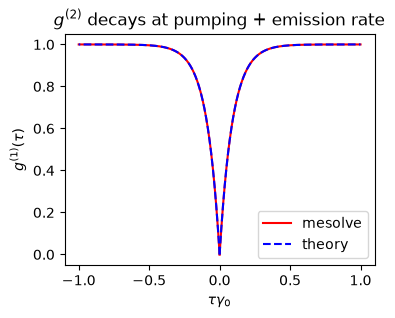

In [41]:
times = np.linspace(0,1,1000)
rho_c = D*rho_ss*D.dag()
result = mesolve(H0,rho_c,times,c_ops,e_ops=[D.dag()*D])
g2 = result.expect[0]/I**2
g2_th = 1-np.exp(-(gamma_P+gamma0)*times)
plt.figure(figsize=(4, 3))
plt.title("$g^{(2)}$ decays at pumping + emission rate")
plt.plot(times,g2.real,color='r',label="mesolve")
plt.plot(-times,g2.real,color='r')
plt.plot(times,g2_th,color='b',ls='--',label="theory")
plt.plot(-times,g2_th,color='b',ls='--')
plt.xlabel(r"$\tau \gamma_{0}$")
plt.ylabel(r"$g^{(1)}(\tau)$")
plt.legend(loc=4)
plt.show()